In [ ]:
import sys
from pathlib import Path
import torch

sys.path.append(str(Path.cwd().parent))

In [ ]:
from src.config import BASE_DIR, DATA_DIR
from src.data import get_dataloaders
from src.metrics import DepthLoss, draw_sample
from src.models import MonocularDepthModel
from src.pipeline import train_step, test_step

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
model = MonocularDepthModel(encoder_name="resnet34", pretrained=True)

train_csv = DATA_DIR / "nyu2_train.csv"
test_csv = DATA_DIR / "nyu2_test.csv"

train_loader, test_loader = get_dataloaders(BASE_DIR, train_csv, test_csv, 32)
images, depths = next(iter(train_loader))
pred_depths = model(images)

print(f"Output image batch: {images.shape}")
print(f"Output depth batch: {pred_depths.shape}")

assert pred_depths.shape == (32, 1, 224, 224), "Error! Shapes don't match"
print("Everything works just fine!")

Output image batch: torch.Size([32, 3, 224, 224])
Output depth batch: torch.Size([32, 1, 224, 224])
Everything works just fine!


In [5]:
model = model.to(device)
for param in model.encoder.parameters():
    param.requires_grad = False
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-3
)
loss = DepthLoss(alpha=0.5)

In [6]:
epochs = 1
for i in range(epochs):
    train_step(model, train_loader, loss, optimizer, device)
    test_step(model, test_loader, loss, device)

Train Loss: 0.59598
Test Loss: 4.53383



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


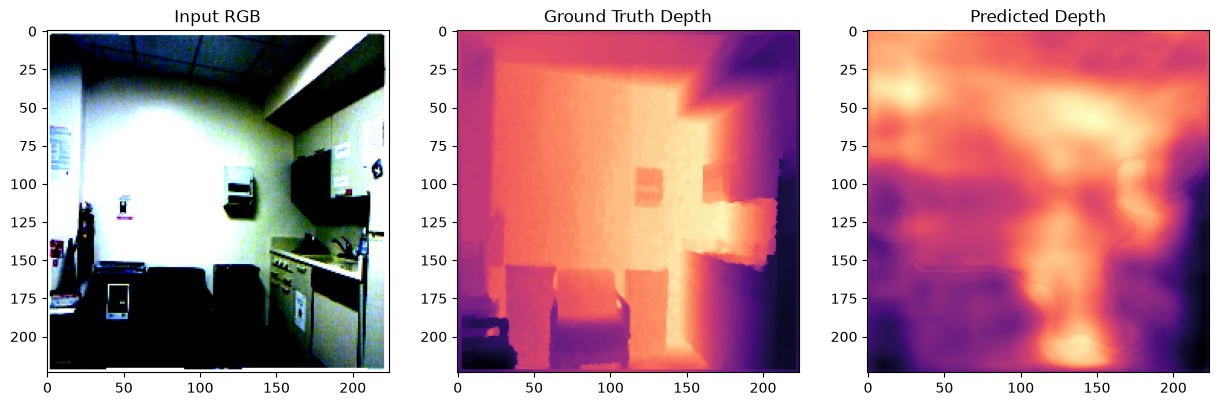

In [7]:
draw_sample(model, test_loader, device)